### Model Training and Evaluation

#### Models evaluated:

- ML: Linear Regression, Random forest and XGBoost
- DL: vanialla model, Tabnet and suggested future work

In [1]:
from pathlib import Path
import copy
import json
import logging
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_folder = repo_root / "data"
model_folder = repo_root / "models"
result_folder = repo_root / "results"
log_folder = repo_root / "logs"
model_folder.mkdir(parents=True, exist_ok=True)
result_folder.mkdir(parents=True, exist_ok=True)
log_folder.mkdir(parents=True, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", handlers=[logging.FileHandler(log_folder / "model_training.log"), logging.StreamHandler()], force=True)
logger = logging.getLogger("farm_model_training")
np.random.seed(42)
torch.manual_seed(42)
logger.info("Model training started")


2026-08-20 13:07:14,939 - INFO - Model training started


In [2]:
# data loading and preparation

train_data = pd.read_csv(data_folder / "train.csv")
validation_data = pd.read_csv(data_folder / "validation.csv")
test_data = pd.read_csv(data_folder / "test.csv")
test_with_anomalies = pd.read_csv(data_folder / "test_with_anomalies.csv")
feature_scaler = joblib.load(data_folder / "feature_scaler.joblib")
target_scaler = joblib.load(data_folder / "target_scaler.joblib")
print("Training shape:", train_data.shape)
print("Validation shape:", validation_data.shape)
print("Clean test shape:", test_data.shape)
print("Anomaly test shape:", test_with_anomalies.shape)
logger.info("Loaded train=%s validation=%s test=%s anomaly_test=%s", train_data.shape, validation_data.shape, test_data.shape, test_with_anomalies.shape)


2026-08-20 13:07:14,949 - INFO - Loaded train=(1052, 12) validation=(225, 12) test=(226, 12) anomaly_test=(226, 19)


Training shape: (1052, 12)
Validation shape: (225, 12)
Clean test shape: (226, 12)
Anomaly test shape: (226, 19)


In [3]:
#standardization checks

feature_columns = ["frequency", "attack-angle", "chord-length", "free-stream-velocity", "suction-side-displacement-thickness"]
standardized_feature_columns = ["frequency_standardized", "attack-angle_standardized", "chord-length_standardized", "free-stream-velocity_standardized", "suction-side-displacement-thickness_standardized"]
target_column = "scaled-sound-pressure"
standardized_target_column = "target_standardized"
required_columns = feature_columns + standardized_feature_columns + [target_column, standardized_target_column]
for dataset_name, dataset in {"train": train_data, "validation": validation_data, "test": test_data}.items():
    missing_columns = [column for column in required_columns if column not in dataset.columns]
    if missing_columns:
        raise ValueError(f"{dataset_name} is missing columns: {missing_columns}")
print("All required training columns are available.")


All required training columns are available.


In [4]:
x_train_original = train_data[feature_columns]
x_validation_original = validation_data[feature_columns]
x_test_original = test_data[feature_columns]
x_train_standardized = train_data[standardized_feature_columns]
x_validation_standardized = validation_data[standardized_feature_columns]
x_test_standardized = test_data[standardized_feature_columns]
y_train_db = train_data[target_column]
y_validation_db = validation_data[target_column]
y_test_db = test_data[target_column]
y_train_standardized = train_data[standardized_target_column]
y_validation_standardized = validation_data[standardized_target_column]

def regression_metrics(y_true, y_prediction):
    return {"MAE": mean_absolute_error(y_true, y_prediction), "RMSE": np.sqrt(mean_squared_error(y_true, y_prediction)), "R2": r2_score(y_true, y_prediction)}

training_rows = []
validation_predictions = {}
trained_models = {}


# 1. Training of all models

## 1a. Machine-learning models

### 1a.1 Linear Regression baseline

Columns used: five standardized feature columns as x; original scaled-sound-pressure in dB as `y`.

Reasoning: scaling is not mandatory for Linear Regression, but it keeps feature magnitudes comparable and makes the coefficient calculation numerically stable. The target stays in dB so predictions are immediately interpretable.


In [5]:
start_time = time.perf_counter()
linear_model = LinearRegression()
linear_model.fit(x_train_standardized, y_train_db)
linear_validation_predictions = linear_model.predict(x_validation_standardized)
training_rows.append({"Family": "ML", "Model": "Linear Regression", "Role": "Baseline", "Training_seconds": time.perf_counter() - start_time, "Best_parameters": "default"})
validation_predictions["Linear Regression"] = linear_validation_predictions
trained_models["Linear Regression"] = linear_model
print("Linear Regression validation metrics:", regression_metrics(y_validation_db, linear_validation_predictions))
logger.info("Linear Regression trained")


2026-08-20 13:07:14,972 - INFO - Linear Regression trained


Linear Regression validation metrics: {'MAE': 3.91110270946436, 'RMSE': np.float64(5.052893546971569), 'R2': 0.47694796452964616}


### 1a.2 Random Forest candidate

Columns used: five original physical feature columns as x; original scaled-sound-pressure in dB as y.

Reasining:  Random Forest creates threshold-based tree splits, so feature scaling is unnecessary. Original units also make feature importance easier to explain. A small grid keeps runtime reasonable.


In [6]:
start_time = time.perf_counter()
random_forest_base = RandomForestRegressor(random_state=42, n_jobs=-1)
random_forest_grid = {"n_estimators": [200, 400], "max_depth": [None, 10], "min_samples_leaf": [1, 2]}
random_forest_search = GridSearchCV(random_forest_base, random_forest_grid, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)
random_forest_search.fit(x_train_original, y_train_db)
random_forest_model = random_forest_search.best_estimator_
random_forest_validation_predictions = random_forest_model.predict(x_validation_original)
training_rows.append({"Family": "ML", "Model": "Random Forest", "Role": "Candidate", "Training_seconds": time.perf_counter() - start_time, "Best_parameters": str(random_forest_search.best_params_)})
validation_predictions["Random Forest"] = random_forest_validation_predictions
trained_models["Random Forest"] = random_forest_model
print("Random Forest best parameters:", random_forest_search.best_params_)
print("Random Forest validation metrics:", regression_metrics(y_validation_db, random_forest_validation_predictions))
logger.info("Random Forest trained with parameters %s", random_forest_search.best_params_)


2026-08-20 13:07:18,588 - INFO - Random Forest trained with parameters {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}


Random Forest best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Random Forest validation metrics: {'MAE': 1.349140711111105, 'RMSE': np.float64(1.8657435342823883), 'R2': 0.9286870356686678}


### 1a. 3 XGBoost training and finetuning 

boosting trees do not need standardized inputs. Original units preserve physical meaning. The small grid tests tree depth, learning rate and number of trees without creating a long search.

In [7]:
start_time = time.perf_counter()
xgboost_base = XGBRegressor(objective="reg:squarederror", tree_method="hist", random_state=42, n_jobs=1)
xgboost_grid = {"n_estimators": [200, 400], "max_depth": [2, 3], "learning_rate": [0.03, 0.05], "subsample": [0.8], "colsample_bytree": [0.8]}
xgboost_search = GridSearchCV(xgboost_base, xgboost_grid, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)
xgboost_search.fit(x_train_original, y_train_db)
xgboost_model = xgboost_search.best_estimator_
xgboost_validation_predictions = xgboost_model.predict(x_validation_original)
training_rows.append({"Family": "ML", "Model": "XGBoost", "Role": "Candidate", "Training_seconds": time.perf_counter() - start_time, "Best_parameters": str(xgboost_search.best_params_)})
validation_predictions["XGBoost"] = xgboost_validation_predictions
trained_models["XGBoost"] = xgboost_model
print("XGBoost best parameters:", xgboost_search.best_params_)
print("XGBoost validation metrics:", regression_metrics(y_validation_db, xgboost_validation_predictions))
logger.info("XGBoost trained with parameters %s", xgboost_search.best_params_)


2026-08-20 13:07:18,724 - INFO - XGBoost trained with parameters {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}


XGBoost best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
XGBoost validation metrics: {'MAE': 1.7436506165907126, 'RMSE': np.float64(2.343386990777177), 'R2': 0.8874999725838605}


## Deep Learning Experiments

### 1b.1 Vanilla PyTorch MLP baseline

Columns: five standardized feature columns as x and target_standardized as y.

Reason: neural networks train more reliably when inputs and targets have similar scales. Predictions are inverse-transformed back to dB before every metric is calculated. Architecture: 5 inputs → 32 → 16 → 1.


In [8]:
x_train_tensor = torch.tensor(x_train_standardized.to_numpy(), dtype=torch.float32)
x_validation_tensor = torch.tensor(x_validation_standardized.to_numpy(), dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_standardized.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_standardized.to_numpy().reshape(-1, 1), dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation_standardized.to_numpy().reshape(-1, 1), dtype=torch.float32)
pytorch_model = nn.Sequential(nn.Linear(5, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.001, weight_decay=0.0001)
print(pytorch_model)


Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [9]:
start_time = time.perf_counter()
maximum_epochs = 400
patience = 30
best_validation_loss = float("inf")
patience_counter = 0
best_model_state = None
training_losses = []
validation_losses = []
for epoch in range(maximum_epochs):
    pytorch_model.train()
    optimizer.zero_grad()
    training_loss = loss_function(pytorch_model(x_train_tensor), y_train_tensor)
    training_loss.backward()
    optimizer.step()
    pytorch_model.eval()
    with torch.no_grad():
        validation_loss = loss_function(pytorch_model(x_validation_tensor), y_validation_tensor)
    training_losses.append(training_loss.item())
    validation_losses.append(validation_loss.item())
    if validation_loss.item() < best_validation_loss:
        best_validation_loss = validation_loss.item()
        best_model_state = copy.deepcopy(pytorch_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= patience:
        break
pytorch_model.load_state_dict(best_model_state)
pytorch_model.eval()
with torch.no_grad():
    pytorch_validation_standardized = pytorch_model(x_validation_tensor).numpy()
pytorch_validation_predictions = target_scaler.inverse_transform(pytorch_validation_standardized).flatten()
training_rows.append({"Family": "DL", "Model": "Vanilla PyTorch MLP", "Role": "Baseline", "Training_seconds": time.perf_counter() - start_time, "Best_parameters": "5-32-16-1, Adam, early stopping"})
validation_predictions["Vanilla PyTorch MLP"] = pytorch_validation_predictions
trained_models["Vanilla PyTorch MLP"] = pytorch_model
print("Stopped after epoch:", epoch + 1)
print("Vanilla PyTorch validation metrics:", regression_metrics(y_validation_db, pytorch_validation_predictions))
logger.info("Vanilla PyTorch trained for %s epochs", epoch + 1)


2026-08-20 13:07:19,485 - INFO - Vanilla PyTorch trained for 400 epochs


Stopped after epoch: 400
Vanilla PyTorch validation metrics: {'MAE': 2.274895308159723, 'RMSE': np.float64(3.1081245802777917), 'R2': 0.8020928726977954}


### 1b.2 TabNetRegressor candidate

Traininf fields: five standardized feature columns as x; target_standardized as y.

TabNet is a PyTorch-based attention architecture for tabular data. Scaling is not strictly required, but standardized inputs and target make its optimization more stable. 

In [10]:
start_time = time.perf_counter()
tabnet_model = TabNetRegressor(n_d=8, n_a=8, n_steps=3, gamma=1.3, seed=42, verbose=10)
tabnet_model.fit(X_train=x_train_standardized.to_numpy(dtype=np.float32), y_train=y_train_standardized.to_numpy(dtype=np.float32).reshape(-1, 1), eval_set=[(x_validation_standardized.to_numpy(dtype=np.float32), y_validation_standardized.to_numpy(dtype=np.float32).reshape(-1, 1))], eval_name=["validation"], eval_metric=["rmse"], max_epochs=150, patience=20, batch_size=128, virtual_batch_size=32, num_workers=0, drop_last=False)
tabnet_validation_standardized = tabnet_model.predict(x_validation_standardized.to_numpy(dtype=np.float32))
tabnet_validation_predictions = target_scaler.inverse_transform(tabnet_validation_standardized).flatten()
training_rows.append({"Family": "DL", "Model": "TabNetRegressor", "Role": "Candidate", "Training_seconds": time.perf_counter() - start_time, "Best_parameters": "n_d=8, n_a=8, n_steps=3, early stopping"})
validation_predictions["TabNetRegressor"] = tabnet_validation_predictions
trained_models["TabNetRegressor"] = tabnet_model
print("TabNet validation metrics:", regression_metrics(y_validation_db, tabnet_validation_predictions))
logger.info("TabNet trained")


/Users/raj/Documents/airbus/airbus-repo/.venv/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.23634 | validation_rmse: 1.19614 |  0:00:00s
epoch 10 | loss: 0.4264  | validation_rmse: 0.65233 |  0:00:02s
epoch 20 | loss: 0.36364 | validation_rmse: 0.58481 |  0:00:05s
epoch 30 | loss: 0.31463 | validation_rmse: 0.50182 |  0:00:07s
epoch 40 | loss: 0.2393  | validation_rmse: 0.4114  |  0:00:09s
epoch 50 | loss: 0.19232 | validation_rmse: 0.41946 |  0:00:12s
epoch 60 | loss: 0.15928 | validation_rmse: 0.46758 |  0:00:14s
epoch 70 | loss: 0.17708 | validation_rmse: 0.39829 |  0:00:17s
epoch 80 | loss: 0.16697 | validation_rmse: 0.35673 |  0:00:19s
epoch 90 | loss: 0.17038 | validation_rmse: 0.37088 |  0:00:22s
epoch 100| loss: 0.15583 | validation_rmse: 0.3293  |  0:00:24s
epoch 110| loss: 0.14206 | validation_rmse: 0.33091 |  0:00:26s
epoch 120| loss: 0.13504 | validation_rmse: 0.40028 |  0:00:29s
epoch 130| loss: 0.16925 | validation_rmse: 0.34308 |  0:00:31s


/Users/raj/Documents/airbus/airbus-repo/.venv/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
2026-08-20 13:07:52,118 - INFO - TabNet trained



Early stopping occurred at epoch 133 with best_epoch = 113 and best_validation_rmse = 0.2962
TabNet validation metrics: {'MAE': 1.5191905349392365, 'RMSE': np.float64(2.045674378761246), 'R2': 0.9142690550412208}


In [11]:
training_summary = pd.DataFrame(training_rows)
print("TRAINING SUMMARY")
display(training_summary)


TRAINING SUMMARY


,Family,Model,Role,Training_seconds,Best_parameters
0,ML,Linear Regression,Baseline,0.009928,default
1,ML,Random Forest,Candidate,3.611147,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
2,ML,XGBoost,Candidate,0.129746,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
3,DL,Vanilla PyTorch MLP,Baseline,0.253456,"5-32-16-1, Adam, early stopping"
4,DL,TabNetRegressor,Candidate,32.628232,"n_d=8, n_a=8, n_steps=3, early stopping"


# 2. Evaluation of ML and DL models

## 2.1 Validation evaluation and model selection

Columns used during evaluation: each model receives the same feature representation it received during training. ML targets and all predictions are evaluated against the original scaled-sound-pressure dB values. Neural-network predictions are inverse-transformed first.

In [12]:
model_families = {"Linear Regression": "ML", "Random Forest": "ML", "XGBoost": "ML", "Vanilla PyTorch MLP": "DL", "TabNetRegressor": "DL"}
validation_results = pd.DataFrame([{"Family": model_families[model_name], "Model": model_name, **regression_metrics(y_validation_db, predictions)} for model_name, predictions in validation_predictions.items()]).sort_values("RMSE").reset_index(drop=True)
best_model_name = validation_results.loc[0, "Model"]
print("ML VALIDATION RESULTS")
display(validation_results[validation_results["Family"] == "ML"].reset_index(drop=True))
print("DL VALIDATION RESULTS")
display(validation_results[validation_results["Family"] == "DL"].reset_index(drop=True))
print("BEST VALIDATION MODEL:", best_model_name)
logger.info("Best validation model: %s", best_model_name)


ML VALIDATION RESULTS


,Family,Model,MAE,RMSE,R2
0,ML,Random Forest,1.349141,1.865744,0.928687
1,ML,XGBoost,1.743651,2.343387,0.887500
2,ML,Linear Regression,3.911103,5.052894,0.476948


DL VALIDATION RESULTS


,Family,Model,MAE,RMSE,R2
0,DL,TabNetRegressor,1.519191,2.045674,0.914269
1,DL,Vanilla PyTorch MLP,2.274895,3.108125,0.802093


2026-08-20 13:07:52,138 - INFO - Best validation model: Random Forest


BEST VALIDATION MODEL: Random Forest


In [13]:
test_predictions = {}
test_predictions["Linear Regression"] = linear_model.predict(x_test_standardized)
test_predictions["Random Forest"] = random_forest_model.predict(x_test_original)
test_predictions["XGBoost"] = xgboost_model.predict(x_test_original)
with torch.no_grad():
    pytorch_test_standardized = pytorch_model(x_test_tensor).numpy()
test_predictions["Vanilla PyTorch MLP"] = target_scaler.inverse_transform(pytorch_test_standardized).flatten()
tabnet_test_standardized = tabnet_model.predict(x_test_standardized.to_numpy(dtype=np.float32))
test_predictions["TabNetRegressor"] = target_scaler.inverse_transform(tabnet_test_standardized).flatten()
test_results = pd.DataFrame([{"Family": model_families[model_name], "Model": model_name, **regression_metrics(y_test_db, predictions)} for model_name, predictions in test_predictions.items()]).sort_values("RMSE").reset_index(drop=True)
print("ML CLEAN-TEST RESULTS")
display(test_results[test_results["Family"] == "ML"].reset_index(drop=True))
print("DL CLEAN-TEST RESULTS")
display(test_results[test_results["Family"] == "DL"].reset_index(drop=True))


ML CLEAN-TEST RESULTS


,Family,Model,MAE,RMSE,R2
0,ML,Random Forest,1.351960,1.844740,0.923594
1,ML,XGBoost,1.669647,2.234814,0.887866
2,ML,Linear Regression,3.641855,4.674627,0.509376


DL CLEAN-TEST RESULTS


,Family,Model,MAE,RMSE,R2
0,DL,TabNetRegressor,1.450293,2.010104,0.909282
1,DL,Vanilla PyTorch MLP,2.068268,2.904096,0.810645


## 2.3 Synthetic-anomaly evaluation

infer with the same five original or standardized feature columns used during training.

observed_sound_pressure_d is compared with the model's expected clean prediction; is_anomaly supplies the synthetic ground truth; anomaly_severity is used for severity recall. None of these three columns is a model input.

Each model receives its own anomaly threshold: the 99th percentile of that model's absolute residuals on the clean validation set. This avoids using anomalous test labels for threshold selection.


In [14]:
x_anomaly_original = test_with_anomalies[feature_columns]
x_anomaly_standardized = test_with_anomalies[standardized_feature_columns]
anomaly_predictions = {}
anomaly_predictions["Linear Regression"] = linear_model.predict(x_anomaly_standardized)
anomaly_predictions["Random Forest"] = random_forest_model.predict(x_anomaly_original)
anomaly_predictions["XGBoost"] = xgboost_model.predict(x_anomaly_original)
x_anomaly_tensor = torch.tensor(x_anomaly_standardized.to_numpy(), dtype=torch.float32)
with torch.no_grad():
    pytorch_anomaly_standardized = pytorch_model(x_anomaly_tensor).numpy()
anomaly_predictions["Vanilla PyTorch MLP"] = target_scaler.inverse_transform(pytorch_anomaly_standardized).flatten()
tabnet_anomaly_standardized = tabnet_model.predict(x_anomaly_standardized.to_numpy(dtype=np.float32))
anomaly_predictions["TabNetRegressor"] = target_scaler.inverse_transform(tabnet_anomaly_standardized).flatten()

anomaly_rows = []
anomaly_details = {}
for model_name, expected_predictions in anomaly_predictions.items():
    threshold_db = np.quantile(np.abs(y_validation_db.to_numpy() - validation_predictions[model_name]), 0.99)
    residuals_db = np.abs(test_with_anomalies["observed_sound_pressure_db"].to_numpy() - expected_predictions)
    predicted_labels = (residuals_db > threshold_db).astype(int)
    true_labels = test_with_anomalies["is_anomaly"].to_numpy()
    anomaly_rows.append({"Family": model_families[model_name], "Model": model_name, "Threshold_dB": threshold_db, "Precision": precision_score(true_labels, predicted_labels, zero_division=0), "Recall": recall_score(true_labels, predicted_labels, zero_division=0), "F1": f1_score(true_labels, predicted_labels, zero_division=0)})
    anomaly_details[model_name] = {"expected": expected_predictions, "residuals": residuals_db, "predicted": predicted_labels, "threshold": threshold_db}
anomaly_results = pd.DataFrame(anomaly_rows).sort_values("F1", ascending=False).reset_index(drop=True)
print("ML ANOMALY RESULTS")
display(anomaly_results[anomaly_results["Family"] == "ML"].reset_index(drop=True))
print("DL ANOMALY RESULTS")
display(anomaly_results[anomaly_results["Family"] == "DL"].reset_index(drop=True))


ML ANOMALY RESULTS


,Family,Model,Threshold_dB,Precision,Recall,F1
0,ML,Random Forest,6.137462,1.000000,0.705882,0.827586
1,ML,XGBoost,7.252749,0.956522,0.647059,0.771930
2,ML,Linear Regression,14.027633,0.909091,0.294118,0.444444


DL ANOMALY RESULTS


,Family,Model,Threshold_dB,Precision,Recall,F1
0,DL,TabNetRegressor,6.240543,0.920000,0.676471,0.779661
1,DL,Vanilla PyTorch MLP,9.975262,0.947368,0.529412,0.679245


### Random Forest and pytroch TabNetRegressor are the best candidates. Random forest performy slightly better and will hence be slected as the model for inferencing

In [15]:
selected_anomaly = anomaly_details[best_model_name]
selected_confusion_matrix = confusion_matrix(test_with_anomalies["is_anomaly"], selected_anomaly["predicted"])
severity_rows = []
for severity in ["low", "moderate", "severe"]:
    severity_mask = test_with_anomalies["anomaly_severity"] == severity
    severity_rows.append({"Severity": severity, "Count": int(severity_mask.sum()), "Detected": int(selected_anomaly["predicted"][severity_mask].sum()), "Recall": float(selected_anomaly["predicted"][severity_mask].mean())})
severity_results = pd.DataFrame(severity_rows)
print("SELECTED MODEL:", best_model_name)
print("SELECTED MODEL CONFUSION MATRIX")
print(selected_confusion_matrix)
print("RECALL BY SEVERITY")
display(severity_results)


SELECTED MODEL: Random Forest
SELECTED MODEL CONFUSION MATRIX
[[192   0]
 [ 10  24]]
RECALL BY SEVERITY


,Severity,Count,Detected,Recall
0,low,11,3,0.272727
1,moderate,11,9,0.818182
2,severe,12,12,1.000000


### Visual representaiton of the evaluation

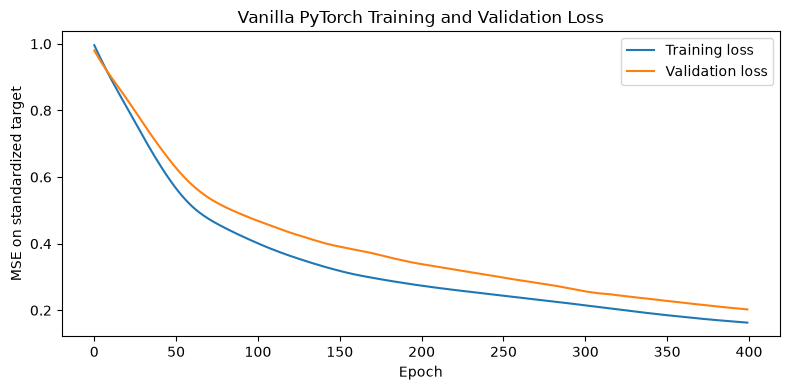

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(training_losses, label="Training loss")
plt.plot(validation_losses, label="Validation loss")
plt.title("Vanilla PyTorch Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE on standardized target")
plt.legend()
plt.tight_layout()
plt.show()


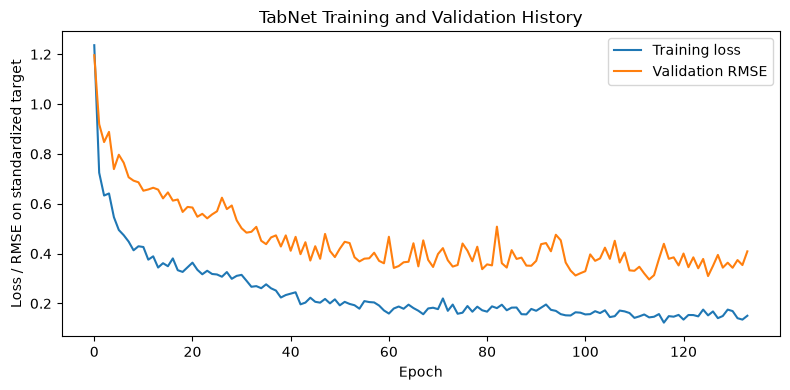

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(tabnet_model.history["loss"], label="Training loss")
plt.plot(tabnet_model.history["validation_rmse"], label="Validation RMSE")
plt.title("TabNet Training and Validation History")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE on standardized target")
plt.legend()
plt.tight_layout()
plt.show()

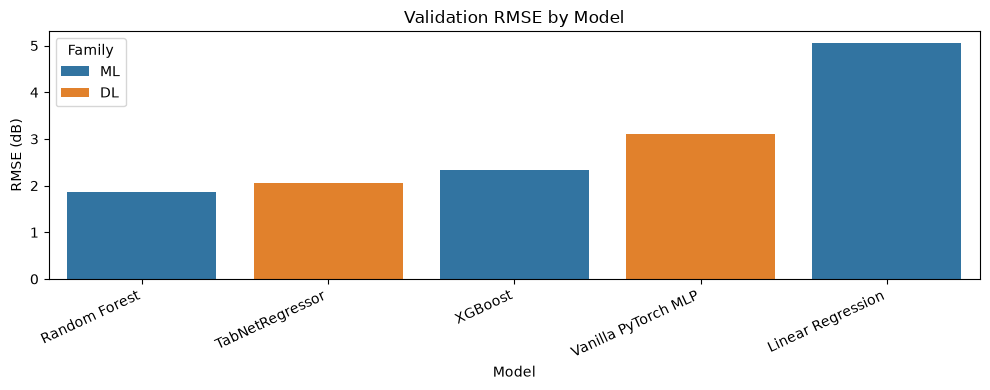

In [17]:
plt.figure(figsize=(10, 4))
sns.barplot(data=validation_results, x="Model", y="RMSE", hue="Family")
plt.title("Validation RMSE by Model")
plt.ylabel("RMSE (dB)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


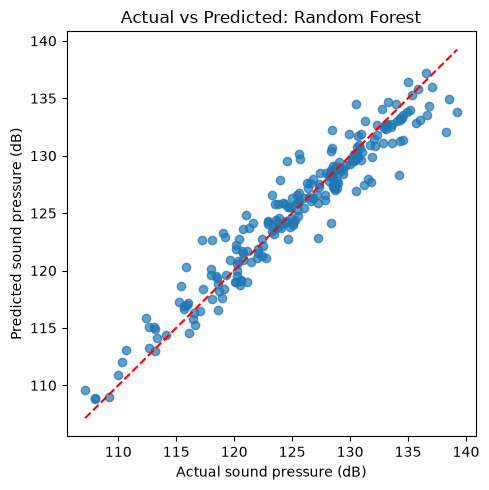

In [18]:
best_test_predictions = test_predictions[best_model_name]
minimum_value = min(y_test_db.min(), best_test_predictions.min())
maximum_value = max(y_test_db.max(), best_test_predictions.max())
plt.figure(figsize=(5, 5))
plt.scatter(y_test_db, best_test_predictions, alpha=0.7)
plt.plot([minimum_value, maximum_value], [minimum_value, maximum_value], "r--")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.xlabel("Actual sound pressure (dB)")
plt.ylabel("Predicted sound pressure (dB)")
plt.tight_layout()
plt.show()


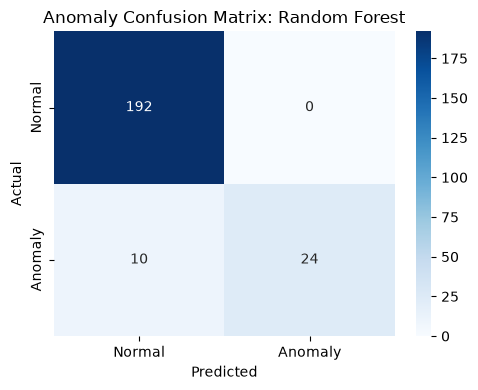

In [19]:
plt.figure(figsize=(5, 4))
sns.heatmap(selected_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title(f"Anomaly Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
